In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('data2.csv')

In [46]:
df

,Study_Hours,Sleep_Hours,Pass
0,1,4,0
1,2,5,0
2,3,6,0
3,4,6,0
4,5,5,1
5,6,5,1
6,7,6,1
7,8,7,1
8,9,7,1
9,10,8,1


In [47]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [48]:
def compute_loss(y, hx):
    epsilon = 1e-10  # Small value to prevent log(0)
    hx = np.clip(hx, epsilon, 1 - epsilon)  # Clip values between epsilon and (1 - epsilon)
    return -np.mean(y * np.log(hx) + (1 - y) * np.log(1 - hx))


In [49]:
def compute_gradient(X,hx,y):
    return np.dot(X.T,(hx-y))

In [50]:
X = np.array([df["Study_Hours"],df["Sleep_Hours"]]).T
y = np.array(df["Pass"])

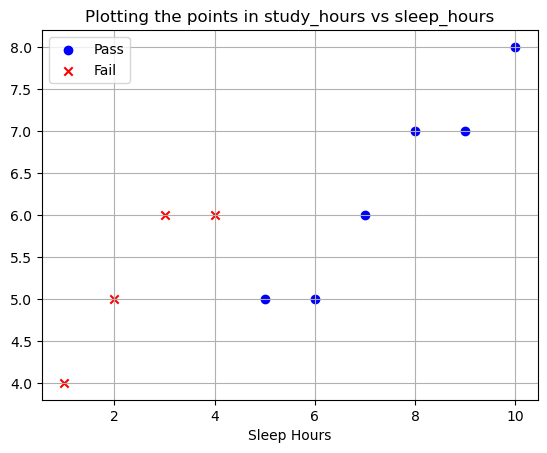

In [51]:
plt.scatter(df["Study_Hours"][y == 1],df["Sleep_Hours"][y == 1],marker='o',c = 'blue',label = 'Pass')
plt.scatter(df["Study_Hours"][y == 0],df["Sleep_Hours"][y == 0],marker='x',c = 'red',label = 'Fail')
plt.title('Plotting the points in study_hours vs sleep_hours')
plt.legend()
plt.grid(True)
plt.xlabel('Study Hours')
plt.xlabel('Sleep Hours')
plt.show()

In [52]:
def logistic_regression(X,y,learning_rate = 0.1,num_iterations = 100):
    X = np.hstack((np.ones((X.shape[0],1)),X))
    weights = np.zeros(X.shape[1])

    for i in range(num_iterations):
        z = np.dot(X,weights)
        hx = sigmoid(z)
        loss = compute_loss(y,hx)
        gradient = compute_gradient(X,hx,y)
        weights -= learning_rate*gradient

    return weights


In [53]:
def plot_decision_boundary(X,y,weights):
    plt.scatter(df["Study_Hours"][y == 1],df["Sleep_Hours"][y == 1],marker='o',c = 'blue',label = 'Pass')
    plt.scatter(df["Study_Hours"][y == 0],df["Sleep_Hours"][y == 0],marker='x',c = 'red',label = 'Fail')
    x_values = np.linspace(df["Study_Hours"].min(),df["Study_Hours"].max(),100)
    y_values = -(weights[0] + weights[1] * x_values) / weights[2]
    plt.plot(x_values,y_values,linestyle = '--',c = 'black')
    plt.title('Plotting the points in study_hours vs sleep_hours')
    plt.legend()
    plt.grid(True)
    plt.xlabel('Study Hours')
    plt.xlabel('Sleep Hours')
    plt.show()

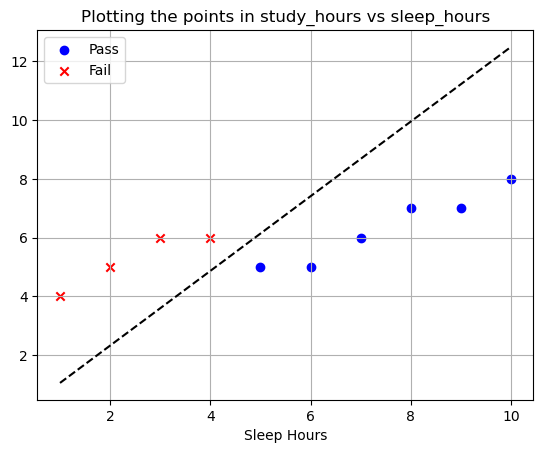

In [54]:
weight = logistic_regression(X,y)
plot_decision_boundary(X,y,weight)